# Imports and setup

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
from scipy.stats import f_oneway, kruskal
from statsmodels.stats.multitest import multipletests
import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages
from lifelines import CoxPHFitter, KaplanMeierFitter
from lifelines.statistics import multivariate_logrank_test

import sys
import warnings

import csv
import pickle

In [ ]:
pd.set_option('display.max_rows', None) 

In [ ]:
warnings.filterwarnings('ignore')
#warnings.filterwarnings('default')

## Define the parameters of your project

In [ ]:
project = {
    'name': 'LysOnc',
    'data_dir': './', 
    'datasets': {
        'TCGA-BRCA': {
            'data': 'expression_data_tcga_brca_TCGA-BRCA_log_fpkm_1226_samples_466_genes.csv',
            'clinical': 'clinical_TCGA-BRCA.csv'
        }  
    }
}

## Load expression data

In [ ]:
data = pd.read_csv('./expression_data_tcga_brca_TCGA-BRCA_log_fpkm_1226_samples_466_genes.csv', sep = ';', index_col=0)
data.head()

## Load clinical data

In [ ]:
expgroup = pd.read_excel('./EpiMed_experimental_grouping_2023.03.16_TCGA-BRCA.xlsx', engine='openpyxl', index_col=0)
available_samples = set(expgroup.index).intersection(set(data.columns))
expgroup = expgroup.loc[list(available_samples)]
expgroup.head()

## Compile gene lists from excel files

In [ ]:
#Demethylases, 1 sheet
genes1 = pd.read_excel("KDMs list.xlsx")
KDMs = [x for x in genes1['Family member'] if x is not np.nan]

In [ ]:
#Transferases, 3 sheets
KMTs = []
for sheet in ['candidate KMTs', 'SET-domain KMTs', '7Bstrand-domain KMTs']:
    genes2 = pd.read_excel("Candidate KMTs.xlsx", sheet_name=sheet)
    if sheet == 'candidate KMTs':
        name_here = 'gene'
    else:
        name_here = 'gene_symbol'
    for x in genes2[name_here]:
        if x not in KMTs:
            KMTs.append(x)

In [ ]:
#Binders, lots of sheets
KMEs = []
genes3 = pd.read_excel("putative KMe binding domain containing proteins.xlsx", sheet_name=None)
for sheet, df in genes3.items():
    if sheet == "Chromo-Chromobarrel":
        name_here = "Name"
    else:
        name_here = "Entry Name"
    for x in df[name_here]:
        if x not in KMEs:
            KMEs.append(x)
            
KMEs.pop()

In [ ]:
#Binders, lots of shits
genes3 = pd.read_excel("putative KMe binding domain containing proteins.xlsx", sheet_name=None)
for sheet, df in genes3.items():
    print(sheet)

## Define a function to execute queries on clinical data

In [ ]:
def get_query(clinical, list_filters):
    query_and = True
    for filter_element in list_filters:
        for colname, colvalues in filter_element.items():
            query_and = query_and & (clinical[colname].isin(colvalues))
    return query_and

## Select a test

In [ ]:
test = 'ANOVA'

In [ ]:
test = 'Kruskal-Wallis'

## 1. Create a template dataframe for results

In [ ]:
gene_list = KDMs.copy()
output_file_name = 'KDM_data'
gene_gr = 'KDM'
output_table1 = pd.DataFrame({'gene_name': KDMs, 'gene group': gene_gr})

In [ ]:
len(gene_list)

In [ ]:
for gene in KMTs:
    gene_list.append(gene)
output_file_name = 'KMT_data'
gene_gr = 'KMT'
output_table2 = pd.DataFrame({'gene_name': KMTs, 'gene group': gene_gr})

In [ ]:
len(gene_list)

In [ ]:
for gene in KMEs:
    gene_list.append(gene)
output_file_name = 'KME_data'
gene_gr = 'KME'
output_table3 = pd.DataFrame({'gene_name': KMEs, 'gene group': gene_gr})

In [ ]:
output_table = pd.concat([output_table1, output_table2, output_table3]).copy()
output_table = output_table.set_index('gene_name')
output_file_name = 'all_genes_data'

In [ ]:
output_table.head()

In [ ]:
output_table = output_table[~output_table.index.duplicated(keep='first')]

In [ ]:
#Results table generation
#for column in ['general p-value', 'general q-value', 'general FDR-adjusted', 
               #'subtype p-value', 'subtype q-value', 'subtype FDR-adjusted', 
               #'basal-like p-value', 'basal-like q-value', 'basal-like FDR-adjusted', 
               #'HER2-enriched p-value', 'HER2-enriched q-value', 'HER2-enriched FDR-adjusted',
              #'luminal-A p-value', 'luminal-A q-value', 'luminal-A FDR-adjusted', 
               #'luminal-B p-value', 'luminal-B q-value', 'luminal-B FDR-adjusted', 
               #'stage p-value', 'stage q-value', 'stage FDR-adjusted', 
               #'n-stage p-value', 'n-stage q-value', 'n-stage FDR-adjusted']:
    #output_table[column] = np.nan

## 2. Define clinical groups
Run one of the cells below, then proceed to the steps 3-6

In [ ]:
groups = {
    # --------------
    'TCGA-BRCA': {
        'NT': [{'tissue_status': ['normal']}], # Non tumour (NT) breast
        'All-tumours': [{'tissue_status': ['tumoral']}],
        },
}
experiment = 'general'

In [ ]:
groups = {
    # --------------
    'TCGA-BRCA': {
        'Luminal-A': [{'tissue_status': ['tumoral']}, {'pam50': ['luminal-A']}],
        'Luminal-B': [{'tissue_status': ['tumoral']}, {'pam50': ['luminal-B']}],
        'HER2-enriched': [{'tissue_status': ['tumoral']}, {'pam50': ['HER2-enriched']}],
        'Basal-like': [{'tissue_status': ['tumoral']}, {'pam50': ['basal-like']}],
        #'Normal-like': [{'tissue_status': ['tumoral']}, {'pam50': ['normal-like']}],
        #'Unknown': [{'tissue_status': ['tumoral']}, {'pam50': [np.nan]}],
        #'Claudin-low': [{'tissue_status': ['tumoral']}, {'claudin_low': [1]}],
        },
}
experiment = 'subtype'

In [ ]:
groups = {
    'TCGA-BRCA': {
        'Basal-like': [
            {'tissue_status': ['tumoral']},
            {'pam50': ['basal-like']}
        ],
        'Other-tumoral': [
            {'tissue_status': ['tumoral']},
            {'pam50': ['luminal-A', 'luminal-B', 'HER2-enriched']}
        ],
    },
}
experiment = 'basal-like'

In [ ]:
groups = {
    'TCGA-BRCA': {
        'luminal-A': [
            {'tissue_status': ['tumoral']},
            {'pam50': ['luminal-A']}
        ],
        'Other-tumoral': [
            {'tissue_status': ['tumoral']},
            {'pam50': ['basal-like', 'luminal-B', 'HER2-enriched']}
        ],
    },
}
experiment = 'luminal-A'

In [ ]:
groups = {
    'TCGA-BRCA': {
        'luminal-B': [
            {'tissue_status': ['tumoral']},
            {'pam50': ['luminal-B']}
        ],
        'Other-tumoral': [
            {'tissue_status': ['tumoral']},
            {'pam50': ['basal-like', 'luminal-A', 'HER2-enriched']}
        ],
    },
}
experiment = 'luminal-B'

In [ ]:
groups = {
    'TCGA-BRCA': {
        'HER2-enriched': [
            {'tissue_status': ['tumoral']},
            {'pam50': ['HER2-enriched']}
        ],
        'Other-tumoral': [
            {'tissue_status': ['tumoral']},
            {'pam50': ['basal-like', 'luminal-B', 'luminal-A']}
        ],
    },
}
experiment = 'HER2-enriched'

In [ ]:
groups = {
    # --------------
   # 'TCGA-BRCA': {
   #     'Stage-I': [{'ajcc_pathologic_tumor_stage_shared_stage_tnm_categories': ['Stage I', 'Stage IA', 'Stage IB']}],
   #     'Stage-II': [{'ajcc_pathologic_tumor_stage_shared_stage_tnm_categories': ['Stage II', 'Stage IIA', 'Stage IIB']}],
   #     'Stage-III': [{'ajcc_pathologic_tumor_stage_shared_stage_tnm_categories': ['Stage III', 'Stage IIIA', 'Stage IIIB', 'Stage IIIC']}],
   #     'Stage-IV': [{'ajcc_pathologic_tumor_stage_shared_stage_tnm_categories': ['Stage IV']}],
        },
}
#experiment = 'stage'

In [ ]:
groups = {
    # --------------
    #'TCGA-BRCA': {
       # 'T1N0': [{'ajcc_tumor_pathologic_pt_shared_stage_pathologic_categories': ['T1', 'T1a', 'T1b', 'T1c']}, {'ajcc_nodes_pathologic_pn_shared_stage_pathologic_m': ['N0', 'N0 (i-)', 'N0 (i+)']}, {'diagnoses_1_ajcc_pathologic_m': ['M0', 'cM0 (i+)']}],
       # 'N0': [{'ajcc_nodes_pathologic_pn_shared_stage_pathologic_m': ['N0', 'N0 (i-)', 'N0 (i+)', 'N0 (mol+)']}, {'diagnoses_1_ajcc_pathologic_m': ['M0', 'cM0 (i+)']}],
       # 'N1': [{'ajcc_nodes_pathologic_pn_shared_stage_pathologic_m': ['N1', 'N1a', 'N1b', 'N1c', 'N1mi']}, {'diagnoses_1_ajcc_pathologic_m': ['M0', 'cM0 (i+)']}],
       # 'N2': [{'ajcc_nodes_pathologic_pn_shared_stage_pathologic_m': ['N2', 'N2a', 'N2b', 'N2c', 'N2mi']}, {'diagnoses_1_ajcc_pathologic_m': ['M0', 'cM0 (i+)']}],
       # 'N3': [{'ajcc_nodes_pathologic_pn_shared_stage_pathologic_m': ['N3', 'N3a', 'N3b', 'N3c', 'N3mi']}, {'diagnoses_1_ajcc_pathologic_m': ['M0', 'cM0 (i+)']}],
       # 'M1': [{'diagnoses_1_ajcc_pathologic_m': ['M1']}],
        },
}
#experiment = 'n-stage'

## 3. Identify the samples belonging to each group and store them inside the project variable 

In [ ]:
dataset_name = 'TCGA-BRCA'
project['datasets'][dataset_name]['groups'] = dict()
clinical = pd.read_csv(project['data_dir'] + project['datasets'][dataset_name]['clinical'], sep=';', index_col=0)
for group_name, list_filters in groups[dataset_name].items():
    query = get_query(clinical, list_filters)
    group_samples = list(clinical.loc[query].index)
    project['datasets'][dataset_name]['groups'][group_name] = group_samples
    print(dataset_name, group_name, len(group_samples))

## 4. Writes sample groups into a csv file

In [ ]:
group_dict =  project['datasets'][dataset_name]['groups'].copy()

#inserts none values to create a csv
max_len = max(len(x) for x in group_dict.values())
for group in group_dict:
    group_dict[group].extend([None] * (max_len - len(group_dict[group])))
    
# write the dictionary to a CSV file
with open('groups.csv', 'w', newline='') as file:
    fieldnames = list(group_dict.keys()) # define fieldnames
    writer = csv.writer(file)
    for i, values in enumerate(group_dict.values()):
        row = [list(group_dict.keys())[i]] + values
        writer.writerow(row)

## 5. Read groups from csv file created earlier

In [ ]:
# read in the CSV file and create a DataFrame
sampling = pd.read_csv('groups.csv', header = None)

# retrieves group names
group_names = [group for group in sampling[0]]

# create a list of Index objects, one for each row containing a group
samples = [pd.Index(data=row[2:]).dropna().set_names([row[1]]) for row in sampling.itertuples()]

## 6. ANOVA analysis
If you did several experiments, repeat steps 2-6 for each sampling, then proceed to step 7

In [ ]:
with PdfPages(f'{output_file_name}_{experiment}_ANOVA_all_groups.pdf') as pdf:
    for gene_name in gene_list:
        try:
            value_series = [data.loc[gene_name, sample] for sample in samples]
        except KeyError:
            continue
        if test == 'ANOVA':
            f_value, p_value = f_oneway(*value_series)
        if test == 'Kruskal-Wallis':
            f_value, p_value = kruskal(*value_series)
        if len(value_series) == 2:
            mean1 = np.mean(value_series[0])
            mean2 = np.mean(value_series[1])

            log2fc = mean1 - mean2
            fc = 2 ** log2fc

            output_table.at[gene_name, f'{experiment} log2FC'] = log2fc
            output_table.at[gene_name, f'{experiment} FC'] = fc
        #print(f_value, p_value)
        output_table.at[gene_name, f'{experiment} p-value'] = p_value
    
# Creates boxplot and send to pdf
        if p_value < 0.05:
            # Create a new figure
            fig, ax = plt.subplots(figsize=(10, 10))
    
            # Create a box plot
            ax.boxplot(value_series)

            # Set the font size and rotation of the tick labels on x-axis
            plt.xticks(range(1, len(group_names) + 1), group_names, rotation=45, ha='right')
                    
            # Set the label of y-axis and title font sizes
            ax.set_ylabel('Expression', fontsize = 16)
            ax.set_title(f'{test} {gene_name}\n p-value = {p_value:.3e}', fontsize=18)
        
            pdf.savefig(fig)
            plt.close()
    output_table.to_excel(f'{output_file_name}_{experiment}_all_groups.xlsx', index=True)

## 7. Eliminating nan values
Run this once; put into the subset ONLY the experiments you've done

In [ ]:
#output_table = output_table.dropna(subset = ['general p-value', 'subtype p-value', 'stage p-value', 'n-stage p-value', 'luminal-A p-value', 'luminal-B p-value', 'HER2-enriched p-value', 'basal-like p-value'])
output_table = output_table.dropna(subset = ['basal-like p-value'])
output_table

## 8. FDR adjustment and significance filtering

### 8.1. Choose your experiment

In [ ]:
experiment = 'general'

In [ ]:
experiment = 'subtype'

In [ ]:
experiment = 'luminal-A'

In [ ]:
experiment = 'luminal-B'

In [ ]:
experiment = 'basal-like'

In [ ]:
experiment = 'HER2-enriched'

In [ ]:
#experiment = 'stage'

In [ ]:
#experiment = 'n-stage'

### 8.2. Run FDR calculations below

In [111]:
# Set the desired FDR threshold
fdr_threshold = 0.1

# Perform multiple testing and adjust p-values
reject, adjusted_p_values, _, _ = multipletests(output_table[f'{experiment} p-value'], alpha=fdr_threshold, method='fdr_bh')

# Shows Benjamini-Hochberg results
output_table[f'{experiment} q-value'] = adjusted_p_values
output_table[f'{experiment} q-value'] = -np.log10(output_table[f'{experiment} q-value'].replace(0, 1e-300))
output_table[f'{experiment} FDR-adjusted'] = reject

### 8.3 Significance based on q-values and fold change

In [120]:
log2fc_col = f'{experiment} log2FC'
fdr_col = f'{experiment} FDR-adjusted'
sig_col = f'{experiment} significant'
log10q_col = f'{experiment} q-value'

output_table[sig_col] = (
    output_table[fdr_col] &
    (output_table[log2fc_col].abs() > np.log2(1.5))
)

### 8.4 Output
"Significant" genes have a fold change > 1.5 with the control group

In [113]:
output_table.to_excel(f'{output_file_name}.xlsx', index=True)

In [114]:
output_table.head()

,gene group,basal-like log2FC,basal-like FC,basal-like p-value,basal-like q-value,basal-like FDR-adjusted,basal-like significant
gene_name,,,,,,,
KDM1A,KDM,0.529376,1.443304,4.822079e-51,49.250440,True,False
KDM1B,KDM,0.462329,1.377765,2.905831e-22,20.992195,True,False
KDM2A,KDM,-0.004466,0.996909,9.153116e-01,0.034687,False,False
KDM2B,KDM,0.369881,1.292246,4.106456e-42,40.458510,True,False
KDM3A,KDM,0.130426,1.094617,6.481975e-04,3.025057,True,False


## 8.5 Volcano plot

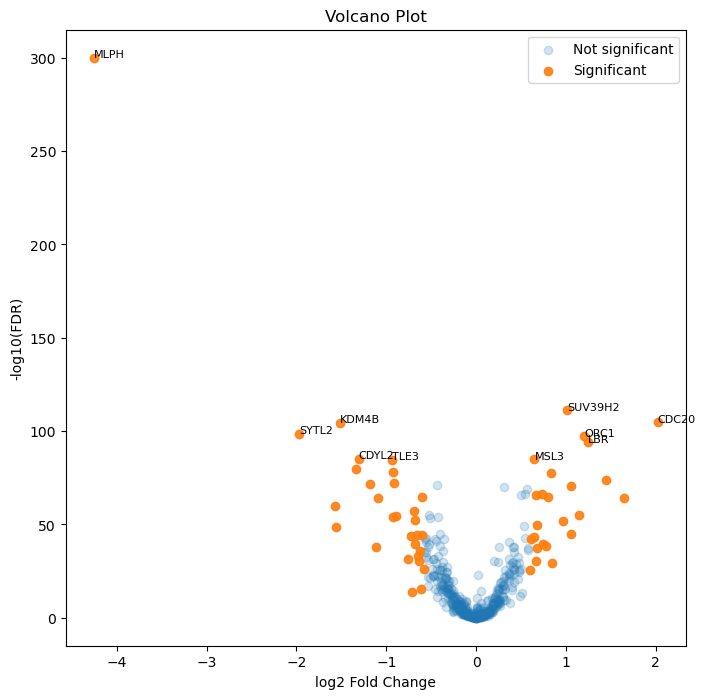

In [132]:
plt.figure(figsize=(8, 8))

# Non-significant
plt.scatter(
    output_table.loc[~output_table[sig_col], log2fc_col],
    output_table.loc[~output_table[sig_col], log10q_col],
    alpha=0.2,
    label='Not significant'
)

# Significant
plt.scatter(
    output_table.loc[output_table[sig_col], log2fc_col],
    output_table.loc[output_table[sig_col], log10q_col],
    alpha=0.9,
    label='Significant'
)

#gene labeling
top = output_table.nlargest(10, log10q_col)

for gene in top.index:
    plt.text(
        output_table.loc[gene, log2fc_col],
        output_table.loc[gene, log10q_col],
        gene,
        fontsize=8
    )
plt.xlabel('log2 Fold Change')
plt.ylabel('-log10(FDR)')
plt.title('Volcano Plot')
plt.legend()

plt.show()

## 8.6 Significant genes for survival analysis

In [135]:
sig_table = output_table[output_table[sig_col]]
sig_table.to_csv(f'{experiment}_significant_genes.csv')

## Saving the project

In [ ]:
pickle_file = f"{project['data_dir']}{project['name']}.pickle"
with open(pickle_file, 'bw') as f:
    pickle.dump(project, f)
print(pickle_file)